## Overview

To examine temporal structure, we used both correlation-based distance and Dynamic Time Warping (DTW). Correlation distance measures how closely time series move together in magnitude, capturing overall synchronization but assuming series are aligned; even small timing differences, such as a peak occurring slightly earlier or later, can reduce similarity. In contrast, DTW aligns series in a flexible, non-linear way, emphasizing shape similarity and allowing peaks, troughs, and other structural features to be matched even when they occur at different times. This makes DTW sensitive to temporal heterogeneity, such as delays, shifts, or stretched patterns.

Comparing correlation and DTW-based clustering across eras serves as a diagnostic tool to identify disagreements and highlight cases in which apparent structural differences are due to temporal misalignment rather than true changes in underlying crime patterns. Applying Z-gap and R-spike to these clusters further identifies natural resolution and dominant regimes, ensuring that clusters reflect meaningful structural differences rather than timing artifacts.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn_extra.cluster import KMedoids
import scipy.cluster.hierarchy as hierarchy
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes
from scipy.stats import zscore, kruskal, ranksums
import scikit_posthocs as sp
from sklearn.metrics import silhouette_score
from sklearn.manifold import MDS, trustworthiness
from scatterd import scatterd
from importlib.metadata import version

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python
import plot
import utils
import zscore_anomaly
import evaluate_clusters

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Pyarrow": pa.__version__, 
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
    "Clusteval": version("clusteval"),
    "Scatterd": version("scatterd"),
    "Scikit Extra": version("scikit-learn-extra"),
    "Scikit Posthocs": version("scikit-posthocs")
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

            Library Version
0            Python  3.13.9
1            Pandas   2.3.3
2             NumPy   2.3.4
3           Pyarrow  22.0.0
4           Seaborn  0.13.2
5           Matplot  3.10.7
6          Sk-Learn   1.8.0
7             Scipy  1.16.3
8         Clusteval   2.2.6
9          Scatterd   1.4.1
10     Scikit Extra   0.3.0
11  Scikit Posthocs  0.12.0


## Data Import

In [2]:
# Read NumPy arrays back into a dictionary
# This keeps your workspace clean instead of creating many loose variables
era_keys = ['pre', 'covid', 'post']
loaded_vecs = {}

# Access them via: loaded_vecs['pre'], etc.
for era in era_keys:
    loaded_vecs[era] = np.load(f'../Data/dist_vec_{era}.npy')


# Read Feather files back into a dictionary
loaded_dfs = {}

for era in era_keys:
    # Read the file into 'data'
    data = pd.read_feather(f"../Data/dist_df_{era}.feather")
    
    # Check for 'fbi_code_desc' OR 'index' to restore the index
    if 'fbi_code_desc' in data.columns:
        data = data.set_index('fbi_code_desc')
    elif 'index' in data.columns:
        data = data.set_index('index')
    
    # Store the correctly indexed dataframe
    loaded_dfs[era] = data

# read crime counts
counts_dfs = {}

for era in era_keys:
    # Read the file into 'data'
    data = pd.read_feather(f"../Data/counts_{era}.feather")
    # Store the correctly indexed dataframe
    counts_dfs[era] = data
    
print("Success! Data loaded and indices restored.") 

Success! Data loaded and indices restored.


## Heat Map Plot

* Dark areas $\rightarrow$ high similarity (distance $\approx$ 0)
* Bright areas $\rightarrow$ low similarity (distance $\approx$ 2)
* Blocks along the diagonal $\rightarrow$ natural clusters

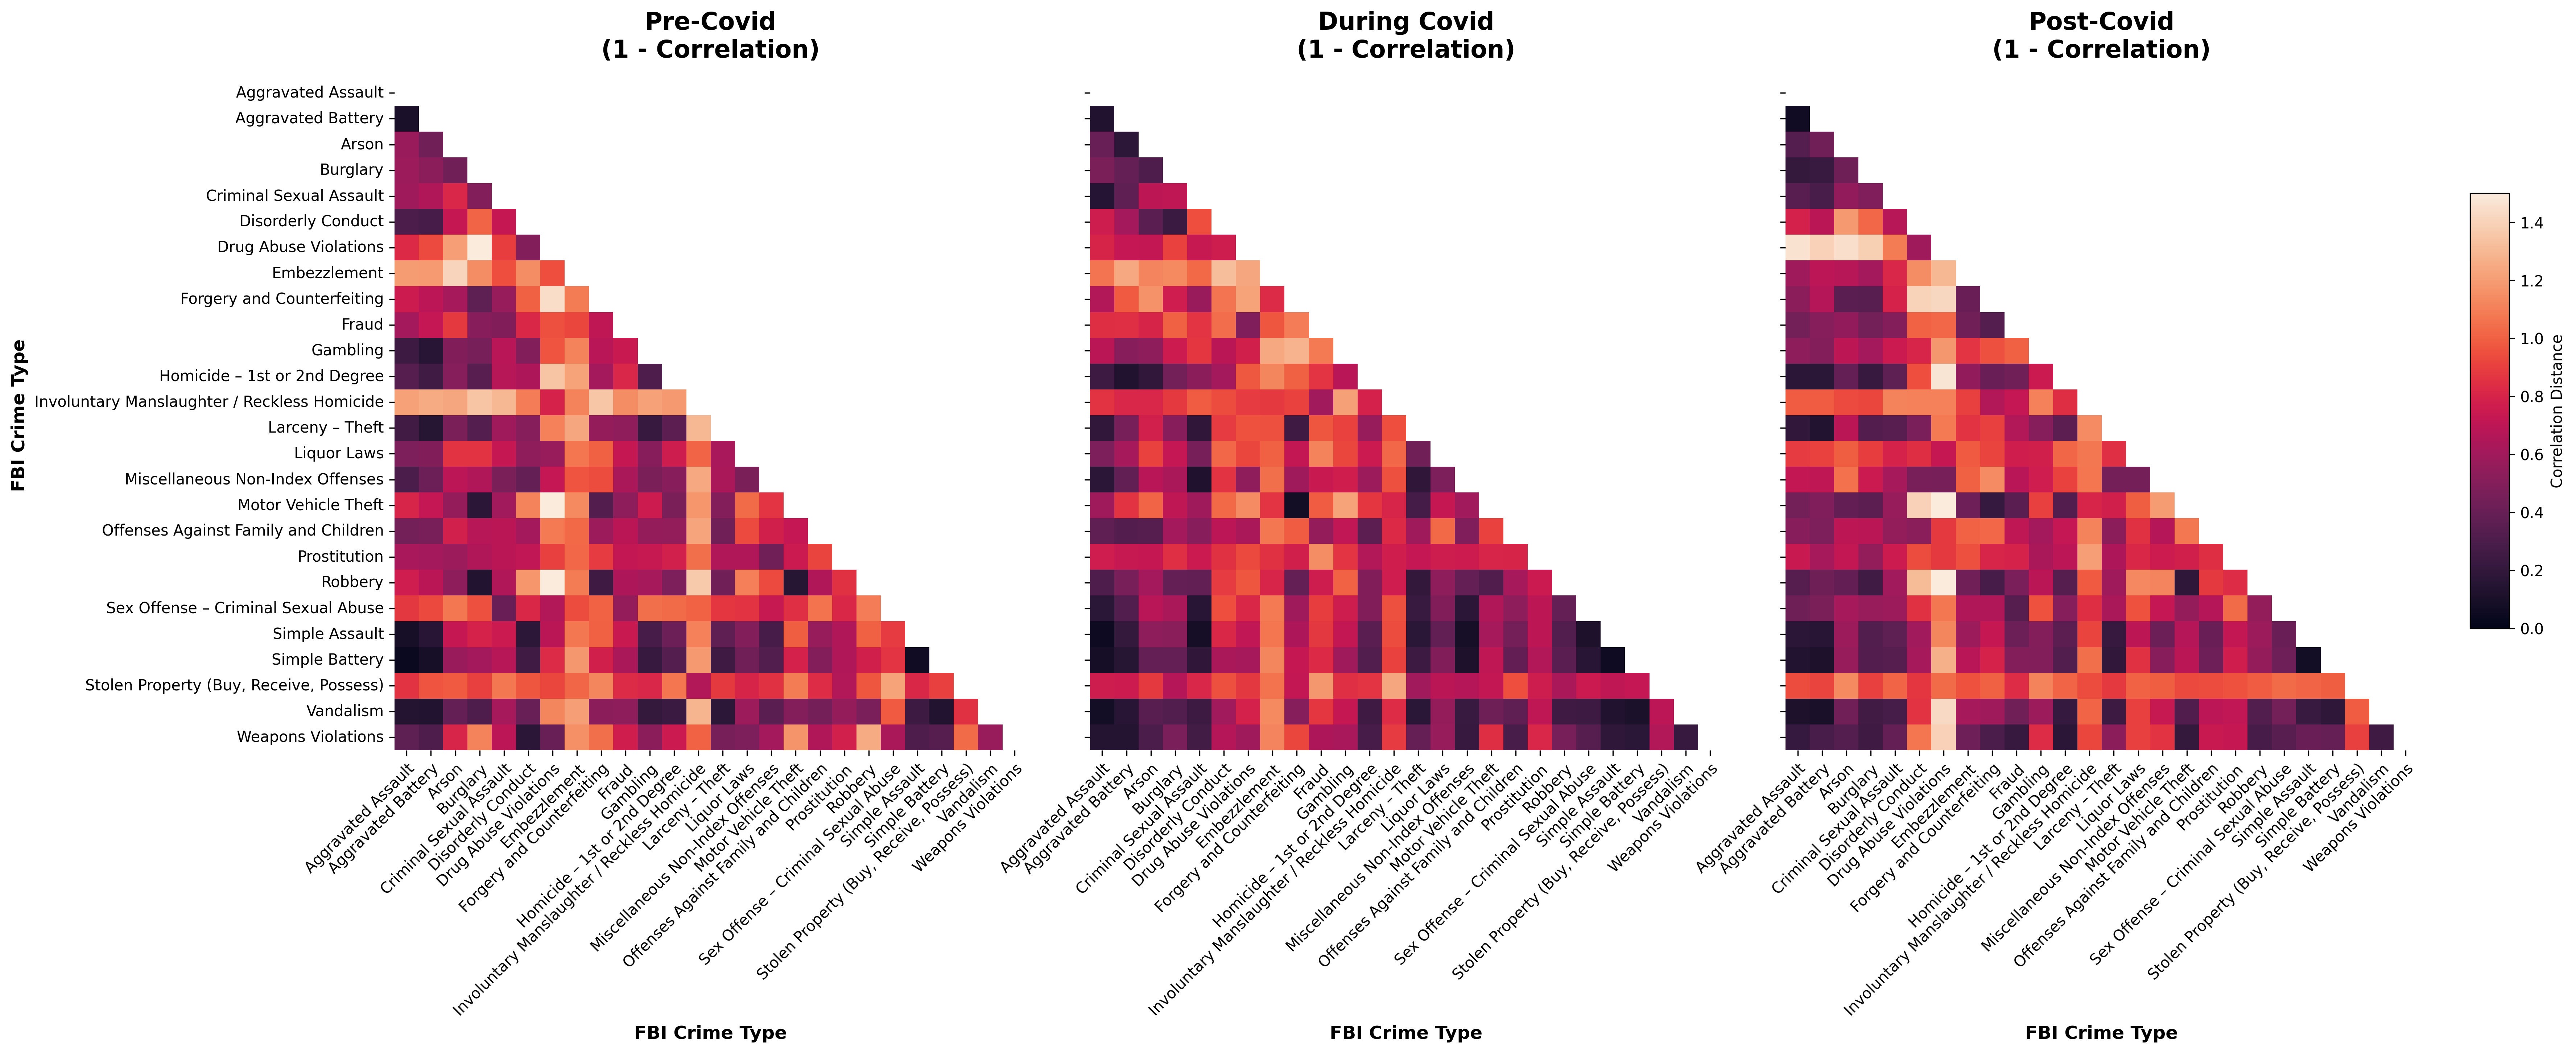

In [3]:
# Configuration
mats = [loaded_dfs['pre'], loaded_dfs['covid'], loaded_dfs['post']]
titles = ["Pre-Covid", "During Covid", "Post-Covid"]

# Heatmap Object
heatmap_kwargs = {
    "cmap": "rocket", 
    "vmin": 0,          
    "vmax": 1.5,        
    "xticklabels": True,
    "yticklabels": True,
    "cbar": False,      # Turn off individual bars to use a single shared one
}

# Increase dpi for crispness; sharey=True is good for comparison
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True, dpi=300)

# Iterate each Plot
for i, (ax, mat, title) in enumerate(zip(axes, mats, titles)):
    # Masking upper triangle
    mask = np.triu(np.ones_like(mat, dtype=bool))
    
    sns.heatmap(mat, ax=ax, mask=mask, **heatmap_kwargs)
    
    # Clean up titles
    ax.set_title(f"{title}\n(1 - Correlation)", fontsize=16, fontweight='bold', pad=15)
    
    # Labeling - Only show Y label on the first plot
    ax.set_xlabel("FBI Crime Type", fontweight='bold', fontsize=12)
    if i == 0:
        ax.set_ylabel("FBI Crime Type", fontweight='bold', fontsize=12)
    else:
        ax.set_ylabel("")

    # Tick handling
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add a single, unified colorbar to the right
mappable = axes[0].get_children()[0]
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5]) # [left, bottom, width, height]
fig.colorbar(mappable, cax=cbar_ax, label='Correlation Distance')

plt.subplots_adjust(right=0.9, wspace=0.1) # Make room for the colorbar
plt.show()

## User Functions(S)

In [4]:
def best_method(cond_dist_dict: dict, msg: str='', methods=None):
    """
    Evaluates hierarchical clustering methods using the Cophenetic Correlation Coefficient.

    This function iterates through different time periods and tests multiple linkage 
    methods to determine which one best preserves the original pairwise distances 
    provided in the distance matrices.

    Args:
        cond_dist_dict (dict): A dictionary where keys are period names (e.g., 'Pre', 'Covid') 
            and values are condensed distance matrices (as returned by scipy.spatial.distance.pdist).
        methods (list, optional): A list of linkage methods to test (e.g., 'complete', 'average', 
            'ward', 'single'). Defaults to ["complete", "average"].

    Returns:
        dict: A nested dictionary containing the results for each period:
            - "best_method": The name of the method with the highest CCC.
            - "best_score": The actual Cophenetic Correlation Coefficient value.
            - "best_linkage": The Scipy linkage matrix (Z) for the winning method.
            - "all_scores": A dictionary of all tested methods and their scores.
    """
    if methods is None:
        methods = ["complete", "average", "median"]

    # To store the final results for each period
    all_results = {}
    
    for period, dist_condensed in cond_dist_dict.items():
        print(f"::: Processing Period: {period.capitalize()} {msg}:::")

        # Dictionary to store CCC for this specific period
        period_ccc = {}
        period_zs = {}
        
        for m in methods:
            # Build linkage matrix
            Z = hierarchy.linkage(dist_condensed, method=m)
            # Calculate Cophenetic Correlation Coefficient
            c, _ = hierarchy.cophenet(Z, dist_condensed)

            # Store results
            period_ccc[m] = c
            period_zs[m] = Z
            # Display
            print(f"Method: {m:8} | CCC: {c:.4f}")

        # Determine the best method for this period
        best_m = max(period_ccc, key=period_ccc.get)
        # Store in main results dict for use
        all_results[period] = {
            "best_method": best_m,
            "best_score": period_ccc[best_m],
            "best_linkage": period_zs[best_m],
            "all_scores": period_ccc
        }
        # Display the winner
        print(f"Winner for {period.capitalize()}: {best_m}\n")
    
    return all_results


def structural_dia(results: dict, msg: str='', depth: int=2):
    """
    Performs structural diagnostics to determine the optimal number of clusters (k).

    This function analyzes the 'best_linkage' matrix for each period (pre, covid, post) 
    using two distinct heuristic approaches: the Global Gap (Z-method) and 
    Local Spikes (R-method). It helps identify if the 'natural' grouping of 
    crime data has fragmented or consolidated across different eras.

    Args:
        results (dict): The output from the `best_method` function, containing 
            'best_linkage' matrices for 'pre', 'covid', and 'post' keys.
        msg (str, optional): An additional string to append to the print headers 
            (e.g., indicating the preprocessing parameters used). Defaults to ''.

    Returns:
        None: Prints the suggested k-values for each period to the console.
    """

    # Iterate through each period to create individual plots
    for period in ['pre', 'covid', 'post']:
        # Retrieve the winning linkage matrix from your best_method function
        Z = results[period]['best_linkage']
        num_entities = Z.shape[0] + 1  # Should be 26
        
        # R-spike Method: Inconsistency Coefficient
        # Calculates: (height - mean_height_below) / std_height_below
        R = hierarchy.inconsistent(Z, d=depth)
        inconsistencies = R[:, 3] 
        
        # Identify links that are "spikes" (highly inconsistent with their children)
        r_spikes = np.where(inconsistencies >= 1.0)[0]
        k_r = len(r_spikes) + 1
    
        # Z-gap Method: Maximum Height Acceleration
        heights = Z[:, 2]
        gaps = np.diff(heights)
        
        # Find the merge step (index) where the largest jump occurs
        z_merge_idx = np.argmax(gaps) 
        
        # Formula: k = (Number of Entities) - (Step index where the gap occurred)
        # This identifies the number of clusters remaining before that bad merge
        k_z = num_entities - z_merge_idx

        # Display msg
        print(f"::: Structural Diagnostics for ({period.upper()}) {msg} :::")
        print(f"Global Gap (Z-method) suggests k = {k_z}")
        print(f"Local Spikes (R-method) suggests k = {k_r}")
        print("-" * 50)

#### Linkage Method
* 'single'     - Nearest point (min distance between clusters) → long thin clusters
* 'complete'   - Farthest point (max distance) → compact spherical clusters  
* 'average'    - Average distance (UPGMA) → balanced, good default
* 'weighted'   - Weighted average → similar to average but size-aware
* 'centroid'   - Centroid distance (UPGMA) → sensitive to outliers
* 'median'     - WPGMC → robust to outliers
* 'ward'       - Minimize variance increase → compact clusters (uses Euclidean only)

#### Rule of thumb:
* With correlation distance, average or complete is usually safest. Single linkage is okay if you want to explore chains, but interpret with caution.

In [5]:
# Run
all_results = best_method(loaded_vecs, msg='Correlation Based Distance')

::: Processing Period: Pre Correlation Based Distance:::
Method: complete | CCC: 0.4983
Method: average  | CCC: 0.8275
Method: median   | CCC: 0.7550
Winner for Pre: average

::: Processing Period: Covid Correlation Based Distance:::
Method: complete | CCC: 0.6355
Method: average  | CCC: 0.8542
Method: median   | CCC: 0.7526
Winner for Covid: average

::: Processing Period: Post Correlation Based Distance:::
Method: complete | CCC: 0.7296
Method: average  | CCC: 0.8142
Method: median   | CCC: 0.7809
Winner for Post: average



Across all periods (Pre, Covid, Post), average linkage consistently produces the highest CCC, making it the most appropriate method for hierarchical clustering with correlation-based distances. Complete linkage often underestimates the global similarity, while the median is slightly less faithful than the average. Using average linkage ensures that dendrograms and subsequent diagnostics (Z-gap, R-spike) reflect the true underlying structure of the time series.

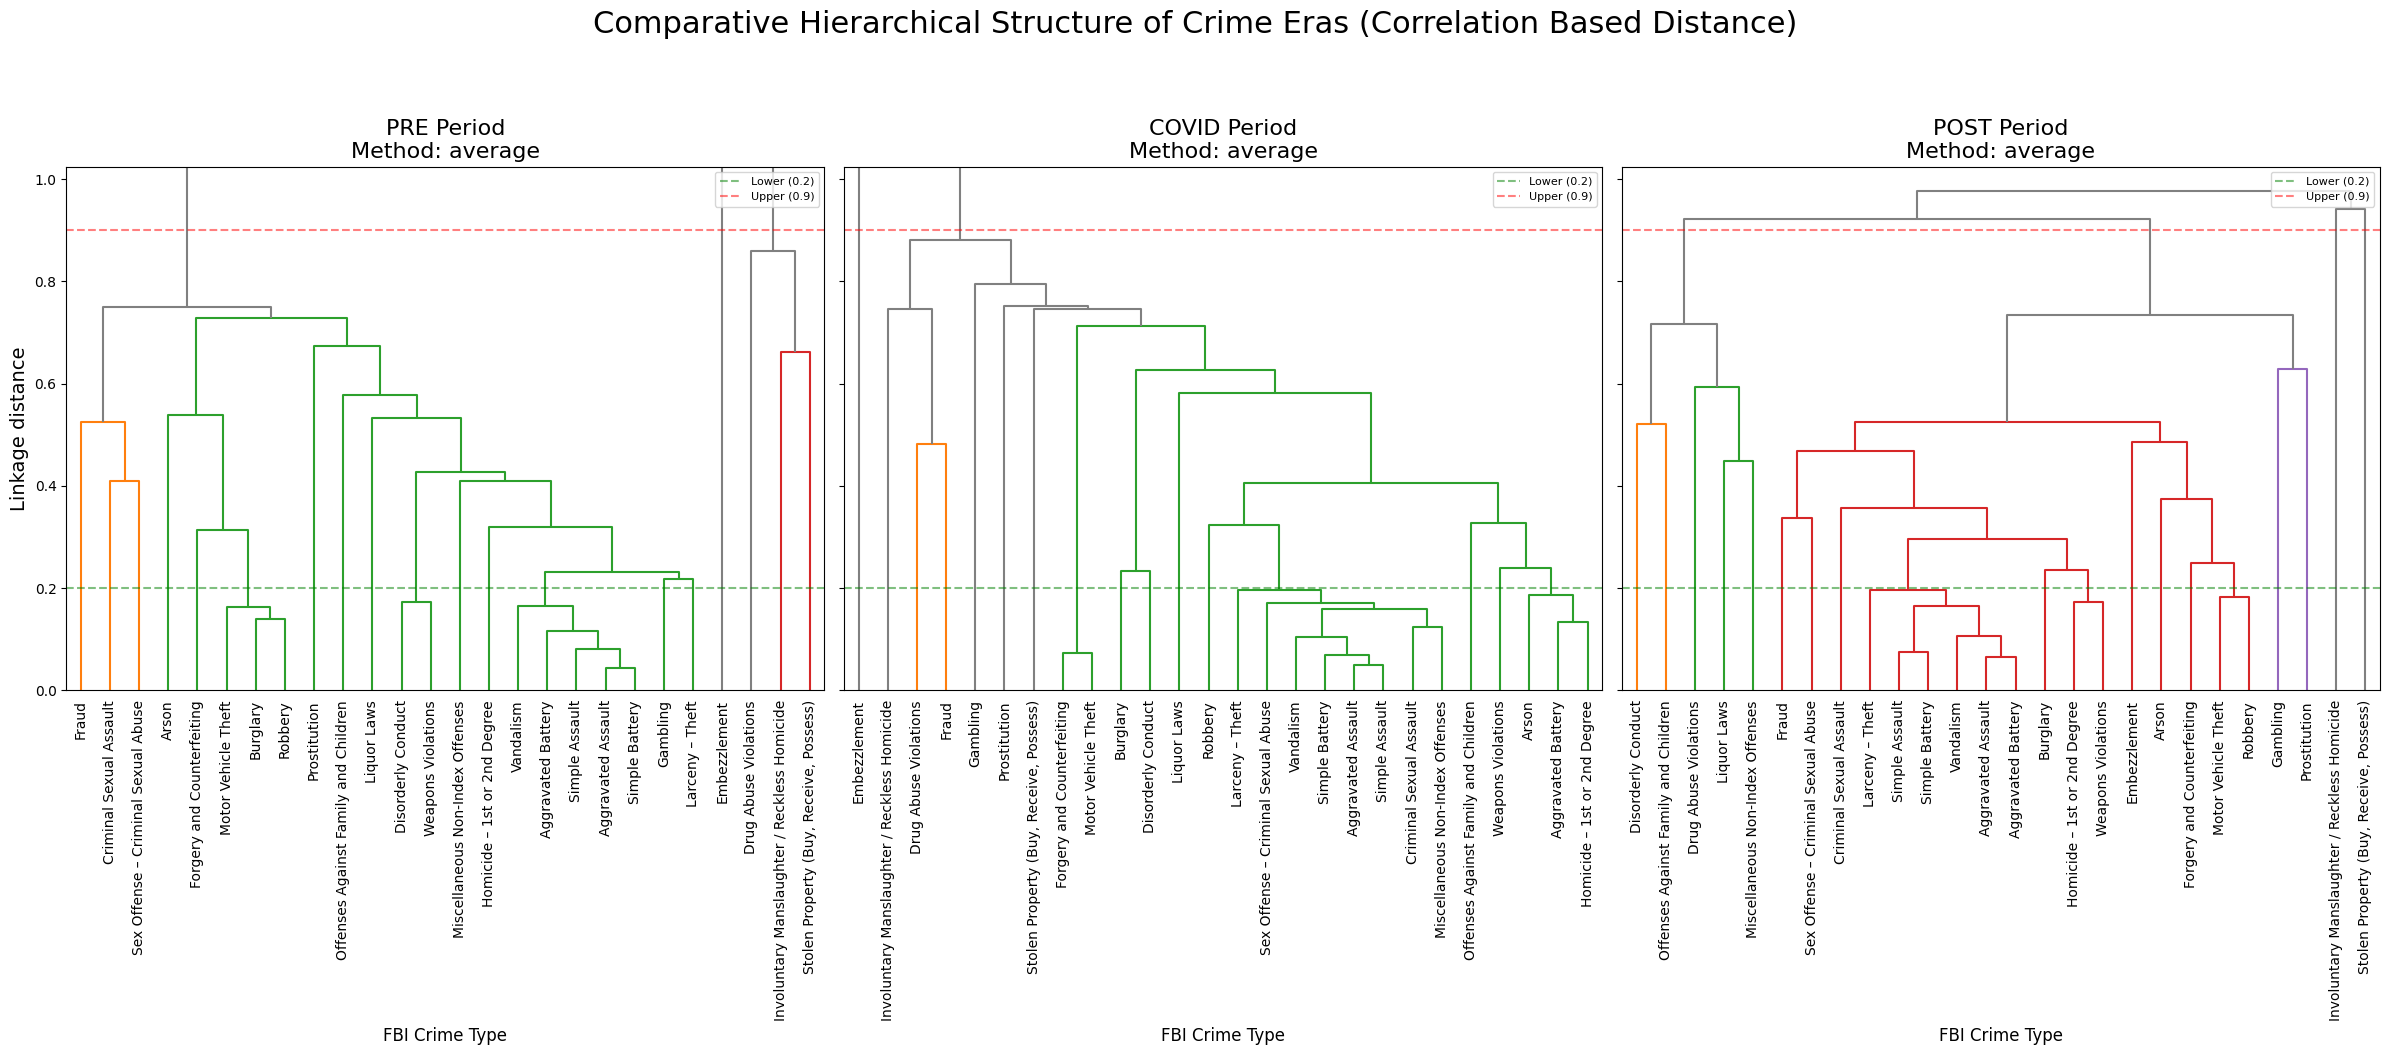

In [6]:
# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)

for i, period in enumerate(['pre', 'covid', 'post']):
    # Retrieve the best linkage and method name for this period
    Z_best = all_results[period]['best_linkage']
    best_m = all_results[period]['best_method']
    ax = axes[i]
    
    # Generate the dendrogram on the specific subplot axis
    hierarchy.dendrogram(
        Z_best, 
        labels=loaded_dfs[period].index, 
        leaf_rotation=90, # Increased rotation for better readability in subplots
        leaf_font_size=10,
        above_threshold_color='gray',
        ax=ax
    )
    
    # Horizontal threshold lines
    ax.axhline(y=0.2, c='g', ls='--', alpha=0.5, label="Lower (0.2)")
    ax.axhline(y=0.9, c='r', ls='--', alpha=0.5, label="Upper (0.9)")
    
    # Formatting
    ax.set_title(f"{period.upper()} Period\nMethod: {best_m}", fontsize=16)
    ax.set_xlabel("FBI Crime Type", fontsize=12)
    
    # Only label the Y-axis for the first plot to avoid clutter
    if i == 0:
        ax.set_ylabel("Linkage distance", fontsize=14)
    
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle("Comparative Hierarchical Structure of Crime Eras (Correlation Based Distance)", fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

#### The Crimes that merge at a very low distance (e.g., $0.1$ or $0.2$) are highly positively correlated in their temporal patterns.

##  Z‑gap / R‑spike
Z‑gap and R‑spike are complementary diagnostics for detecting structural changes in hierarchical clustering. Z‑gap identifies candidate cluster counts by finding large global jumps in cohesion, revealing the natural resolution of the data. R‑spike highlights locally dominant clusters that are particularly robust, emphasizing strong, interpretable structure over fine-grained micro-variation. Together, they help determine both plausible and meaningful cluster resolutions across eras.

In [7]:
structural_dia(all_results, msg='Correlation Based Distance')

::: Structural Diagnostics for (PRE) Correlation Based Distance :::
Global Gap (Z-method) suggests k = 4
Local Spikes (R-method) suggests k = 1
--------------------------------------------------
::: Structural Diagnostics for (COVID) Correlation Based Distance :::
Global Gap (Z-method) suggests k = 3
Local Spikes (R-method) suggests k = 4
--------------------------------------------------
::: Structural Diagnostics for (POST) Correlation Based Distance :::
Global Gap (Z-method) suggests k = 5
Local Spikes (R-method) suggests k = 9
--------------------------------------------------


* Z-gap captures the global "natural resolution" of clusters where adding clusters gives unusually large improvements in cohesion.
* R-spike identifies strong local regimes, emphasizing robust clusters that stand out even when fine-grained structure exists.
* Across periods, the number of local spikes increases, especially post-Covid, suggesting greater temporal heterogeneity in correlation patterns.
    * Temporal trends:
        * Pre: Mostly synchronized, one dominant cluster
        * Covid: Emergence of heterogeneity with multiple local regimes
        * Post: Increased fine-grained structure, many robust local clusters

:::::::::::::::::::::::::::::::::::::::::::::::::: Correlation Based Distance



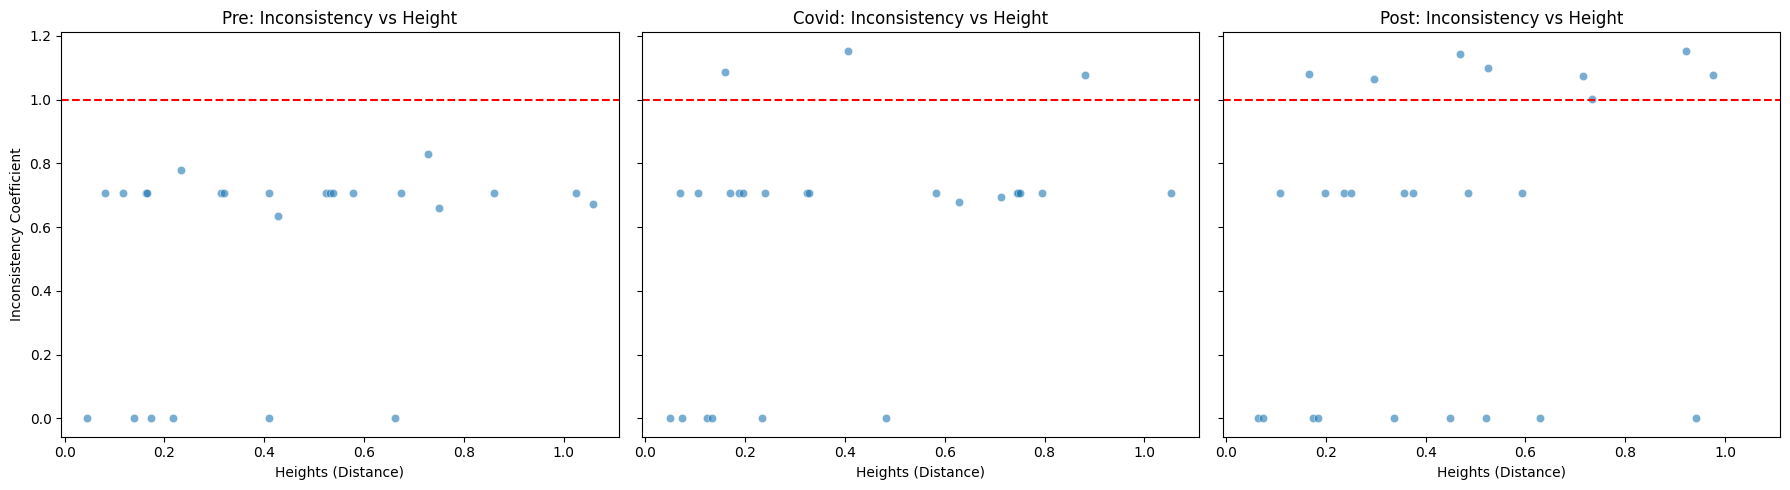

In [8]:
# Setup the figure with 3 subplots
print(f"{':'* 50} Correlation Based Distance\n")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)
eras = ['pre', 'covid', 'post']
titles = ['Pre: Inconsistency vs Height', 'Covid: Inconsistency vs Height', 'Post: Inconsistency vs Height']

for i, era in enumerate(eras):
    # Get the linkage matrix for the specific era
    Z = all_results[era]['best_linkage']
    
    # Calculate Inconsistency (depth=2 is standard)
    # R columns: [mean, std, count, inconsistency_coefficient]
    R = hierarchy.inconsistent(Z, d=2)
    # Initialize variables
    heights = Z[:, 2]             # Distance at which clusters merge
    inconsistencies = R[:, 3]     # How 'natural' the clusters are
    
    # Plot on the specific axis
    sns.scatterplot(x=heights, y=inconsistencies, ax=axes[i], alpha=0.6)
    
    # Formatting
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Heights (Distance)")
    axes[i].axhline(1.0, color='red', linestyle='--', label='Threshold (1.0)')
    
    if i == 0:
        axes[i].set_ylabel("Inconsistency Coefficient")

plt.tight_layout()
plt.show()

## Analysis of the Transitions

In [9]:
def stat_analysis(cond_dist_dict: dict, msg='Correlation Based Distance'):
    # Combine the condensed distance vectors into a single list for the test
    data = [cond_dist_dict['pre'], cond_dist_dict['covid'], cond_dist_dict['post']]
    
    # Statistical Testing (Omnibus)
    h_stat, p_kruskal = kruskal(*data)
    
    # Post-hoc Testing (Pairwise)
    # Using Bonferroni correction for 3 comparisons (alpha = 0.05 / 3 = 0.0167)
    comparisons = [("Pre vs Covid", cond_dist_dict['pre'], cond_dist_dict['covid']), 
                   ("Covid vs Post", cond_dist_dict['covid'], cond_dist_dict['post']), 
                   ("Pre vs Post", cond_dist_dict['pre'], cond_dist_dict['post'])]
    
    results = []
    for label, v1, v2 in comparisons:
        stat, p_val = ranksums(v1, v2)
        results.append({
            "Comparison": label,
            "P-Value": round(p_val, 4),
            "Significant": p_val < 0.0167, # Adjusted Alpha: 0.05 / 3 = 0.01666
            "Median Diff": round(np.median(v2) - np.median(v1), 4)
        })
    
    # Display Results
    print(f"{":"*10} {msg} {":"*10}\n")
    print(f"Kruskal-Wallis Test: H={h_stat:.4f}, p={p_kruskal:.4f}")
    print("\nPairwise Comparisons:")
    print(pd.DataFrame(results))
    
    print("\nMedian Distances (Lower = More Synchronized):")
    print(f"Pre: {np.median(cond_dist_dict['pre']):.4f} | Covid: {np.median(cond_dist_dict['covid']):.4f} | Post: {np.median(cond_dist_dict['post']):.4f}")

    # Bonferroni or Holm are recommended to avoid False Positives
    p_values = sp.posthoc_dunn(data, p_adjust='bonferroni')
    # p_values = sp.posthoc_dunn(data, p_adjust='holm')
    
    # Rename columns/rows for clarity
    p_values.columns = ['Pre', 'Covid', 'Post']
    p_values.index = ['Pre', 'Covid', 'Post']
    
    print(f"\nDunn's Test:")
    print(p_values)

    return

In [10]:
# Run test
stat_analysis(loaded_vecs)

:::::::::: Correlation Based Distance ::::::::::

Kruskal-Wallis Test: H=6.5701, p=0.0374

Pairwise Comparisons:
      Comparison  P-Value  Significant  Median Diff
0   Pre vs Covid   0.0127         True      -0.0146
1  Covid vs Post   0.2812        False      -0.0104
2    Pre vs Post   0.1145        False      -0.0250

Median Distances (Lower = More Synchronized):
Pre: 0.7119 | Covid: 0.6973 | Post: 0.6869

Dunn's Test:
            Pre     Covid      Post
Pre    1.000000  0.032611  0.382582
Covid  0.032611  1.000000  0.919045
Post   0.382582  0.919045  1.000000


The Kruskal-Wallis test yielded an `H-statistic of 6.5701` and a `p-value of 0.0374`, which is below the `0.05 significance threshold`. This indicates a statistically significant difference in correlation-based distances across the Pre, Covid, and Post periods. Consequently, Dunn’s post-hoc test and hierarchical clustering diagnostics should be applied to identify which periods differ and to explore underlying structural patterns.

#### Dunn's Test
**Pre $\rightarrow$ COVID**
* Statistical Validation ($p = 0.0326$): This jump is statistically significant.
* This strongly validates why the R-spike jumped from $k=1$ to $k=4$. The Dunn’s test confirms that the correlation distances in the Covid era are not just slightly different, they are a different population. Since the p-value is below $0.05$, we can confidently say the "distance" between our variables changed fundamentally, and there is a genuine structural shift.

**COVID $\rightarrow$ Post-COVID**
* Statistical Validation ($p = 0.9190$): This is not significant.
* Even though our $k$ jumped to 9, the distribution of the data did not change. This usually happens when the "bulk" of our correlations stays the same, but a few specific pairs become extreme outliers. R-spike is extremely sensitive to these "tail" outliers, whereas Dunn's test (based on ranks) ignores them. Since the $p$-value is so high, but our R-spike leaped to $k=9$, Dunn’s test is essentially providing a warning that the $k=9$ is likely driven by extreme outliers (spikes) rather than a whole change in the entire dataset. There is a specific phenomenon where the "bulk" of your variables still behaves normally, but a small group has "broken off" and become extremely disconnected or erratic (fractured at the edges).

**Pre $\rightarrow$ Post-COVID**
* Statistical Validation ($p = 0.3826$): This is not significant.
* This suggests that the Post-COVID data is actually trying to revert to the Pre-COVID structure. However, it is much "noisier" or "spikier" than it used to be, which is why R-spike signals $k=9$. The reason R-spike shows a $k=9$ while the p-value shows "no difference" is likely due to the variance and outliers in our distance vectors.

## Z-Gap

In [11]:
def run_kmedoids(dist_matrix, k, labels, era_name="Era"):
    if dist_matrix.ndim == 1:
        dist_matrix = squareform(dist_matrix, checks=False)

    kmed = KMedoids(n_clusters=k, metric='precomputed', random_state=SEED)
    cluster_ids = kmed.fit_predict(dist_matrix)
    # anchors
    anchors = kmed.medoid_indices_
    inertia = kmed.inertia_
    sil_score = silhouette_score(dist_matrix, cluster_ids, metric='precomputed')

    print(f"\n::: {era_name} Results & total distance clustering has (Inertia):"
          f"{inertia:.4f} with Silhouette Score: {sil_score:.3f} :::")
    
    # Use range(k) to avoid tuple errors from zip
    for cluster_idx in range(k):
        # Get indices of crimes in this cluster
        member_indices = np.where(cluster_ids == cluster_idx)[0]
        cluster_crimes = [labels[j] for j in member_indices]
        
        # Get the Medoid (the actual crime that is the center)
        medoid_name = labels[kmed.medoid_indices_[cluster_idx]]
        
        print(f"Cluster {cluster_idx + 1} [Medoid: {medoid_name}]:")
        print(f"  {', '.join(cluster_crimes[:5])}...")

    return cluster_ids, anchors


def calculate_cluster_tightness(dist_matrix, cluster_ids, medoid_indices, labels):
    if dist_matrix.ndim == 1:
        dist_matrix = squareform(dist_matrix)
        
    tightness_results = []
    
    for cluster_idx in np.unique(cluster_ids):
        # Get members of this cluster
        member_indices = np.where(cluster_ids == cluster_idx)[0]
        
        # Get the distance from each member to the specific medoid for this cluster
        medoid_idx = medoid_indices[cluster_idx]
        distances_to_medoid = dist_matrix[member_indices, medoid_idx]
        
        avg_dist = np.mean(distances_to_medoid)
        max_dist = np.max(distances_to_medoid)
        
        tightness_results.append({
            'Cluster': cluster_idx + 1,
            'Medoid': labels[medoid_idx],
            'Avg_Dist_to_Medoid': avg_dist,
            'Max_Dist_to_Medoid': max_dist,
            'Cluster_Size': len(member_indices)
        })
        
        
    return pd.DataFrame(tightness_results)

In [12]:
# Crime Labels ( all the same for three eras
crime_labels = loaded_dfs['pre'].index.to_list()

# Run at your diagnostic k values
pre_clusters, anchors_pre = run_kmedoids(loaded_vecs['pre'], k=4, labels=crime_labels, era_name= 'Pre-COVID Correlation Based Distance')
covid_clusters, anchors_covid = run_kmedoids(loaded_vecs['covid'], k=3, labels=crime_labels, era_name= 'COVID Correlation Based Distance') 
post_clusters, anchors_post = run_kmedoids(loaded_vecs['post'], k=5, labels=crime_labels, era_name= 'Post-COVID Correlation Based Distance')


::: Pre-COVID Correlation Based Distance Results & total distance clustering has (Inertia):9.7384 with Silhouette Score: 0.054 :::
Cluster 1 [Medoid: Burglary]:
  Burglary, Criminal Sexual Assault, Forgery and Counterfeiting, Fraud, Motor Vehicle Theft...
Cluster 2 [Medoid: Aggravated Battery]:
  Aggravated Battery, Arson, Gambling, Homicide – 1st or 2nd Degree, Larceny – Theft...
Cluster 3 [Medoid: Aggravated Assault]:
  Aggravated Assault, Liquor Laws, Offenses Against Family and Children, Sex Offense – Criminal Sexual Abuse, Simple Battery...
Cluster 4 [Medoid: Simple Assault]:
  Disorderly Conduct, Drug Abuse Violations, Embezzlement, Involuntary Manslaughter / Reckless Homicide, Miscellaneous Non-Index Offenses...

::: COVID Correlation Based Distance Results & total distance clustering has (Inertia):9.7181 with Silhouette Score: 0.026 :::
Cluster 1 [Medoid: Vandalism]:
  Arson, Burglary, Disorderly Conduct, Forgery and Counterfeiting, Involuntary Manslaughter / Reckless Homicide

In [13]:
# Run for the Pre era
post_tightness = calculate_cluster_tightness(loaded_vecs['pre'], pre_clusters, anchors_pre, crime_labels)

print("\n::: Pre-COVID Correlation Based Distance Results :::")
post_tightness


::: Pre-COVID Correlation Based Distance Results :::


,Cluster,Medoid,Avg_Dist_to_Medoid,Max_Dist_to_Medoid,Cluster_Size
0,1,Burglary,0.281967,0.514266,6
1,2,Aggravated Battery,0.257369,0.611259,8
2,3,Aggravated Assault,0.367851,0.876056,5
3,4,Simple Assault,0.592629,1.102981,7


In [14]:
# Run for the Covid era
post_tightness = calculate_cluster_tightness(loaded_vecs['covid'], covid_clusters, anchors_covid, crime_labels)

print("\n::: COVID Correlation Based Distance Results :::")
post_tightness


::: COVID Correlation Based Distance Results :::


,Cluster,Medoid,Avg_Dist_to_Medoid,Max_Dist_to_Medoid,Cluster_Size
0,1,Vandalism,0.413422,0.833088,10
1,2,Simple Battery,0.423435,0.820316,7
2,3,Aggravated Assault,0.291087,1.065240,9


In [15]:
# Run for the Post era
post_tightness = calculate_cluster_tightness(loaded_vecs['post'], post_clusters, anchors_post, crime_labels)

print("\n::: Post Correlation Based Distance Results :::")
post_tightness


::: Post Correlation Based Distance Results :::


,Cluster,Medoid,Avg_Dist_to_Medoid,Max_Dist_to_Medoid,Cluster_Size
0,1,Weapons Violations,0.335072,0.902295,9
1,2,Aggravated Battery,0.244352,0.616472,7
2,3,Miscellaneous Non-Index Offenses,0.340741,0.460491,4
3,4,Vandalism,0.139670,0.279340,2
4,5,Simple Assault,0.349741,0.918585,4


## [MDS (Multidimensional Scaling)](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html)
* definitive map of how the relationships (correlations) changed over the 300 months
## [Procrustes Analysis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.procrustes.html)
* A statistical method for shape analysis used to compare two sets of data points (shapes)

In [16]:
def mds_analysis(data = loaded_dfs, n_components = 3, msg = "Correlation Based Distance", n_init = 4, max_iter = 500):
    # Initialize variables
    mds_results = {}
    reference_coords = None  # Pre-COVID as the anchor
    # Ensure periods are processed in order: Pre -> Covid -> Post
    periods = ['pre', 'covid', 'post'] 

    # Iterate
    for period in periods:
        if period not in data: continue
        
        # Initialize MDS on distance matrix (26 × 26)
        # Note: dissimilarity is the correct param for precomputed matrices
        mds = MDS(
            n_components=n_components,
            metric='precomputed',   # use precomputed distances
            n_init=n_init if n_components > 2 else 1, 
            init = 'random' if n_components > 2 else 'classical_mds',
            max_iter=max_iter,
            normalized_stress=True,
            random_state=SEED
        )
        
        # Fit and Transform
        coords_mds = mds.fit_transform(data[period].values)
        
        # Procrustes Alignment
        if period == 'pre':
            # Set the reference frame
            reference_coords = coords_mds
            aligned_coords = coords_mds
            disparity = 0.0
        else:
            # Align Covid/Post to the Pre-COVID 'Normal'
            # mds_aligned will be the coords rotated/scaled to match 'pre'
            _, aligned_coords, disparity = procrustes(reference_coords, coords_mds)
    
        # Calculate Variance Ratio
        mds_vars = np.var(aligned_coords, axis=0)
        mds_var_ratio = mds_vars / np.sum(mds_vars)
        
        # Store Results
        mds_results[period] = {
            'coords': aligned_coords,        # Use aligned version for plotting
            'raw_coords': coords_mds,        # Keep raw for reference
            'winning_iteration': {mds.n_iter_},
            'stress': mds.stress_,
            'components': n_components,
            'disparity_to_pre': disparity,   # Higher = more structural change
            'var_ratio': mds_var_ratio
        }
    
        # Display
        print(f"::: Processing Period: {period.capitalize()} {msg} :::")
        print("MDS Dimension Importance (Relative Variance): " + " & ".join(
        [f"Dim{i+1} = {v:.2%}" for i, v in enumerate(mds_var_ratio)]
        ))
        # Stress value
        print(f"Kruskal's Stress-1: {mds.stress_:.4f} with {n_components} components.\n")

    return mds_results

In [17]:
# MDS
mds_results = mds_analysis(loaded_dfs, n_components = 3, msg = "Correlation Based Distance")

::: Processing Period: Pre Correlation Based Distance :::
MDS Dimension Importance (Relative Variance): Dim1 = 30.19% & Dim2 = 25.40% & Dim3 = 44.41%
Kruskal's Stress-1: 0.1173 with 3 components.

::: Processing Period: Covid Correlation Based Distance :::
MDS Dimension Importance (Relative Variance): Dim1 = 34.19% & Dim2 = 31.30% & Dim3 = 34.51%
Kruskal's Stress-1: 0.1212 with 3 components.

::: Processing Period: Post Correlation Based Distance :::
MDS Dimension Importance (Relative Variance): Dim1 = 30.03% & Dim2 = 27.23% & Dim3 = 42.73%
Kruskal's Stress-1: 0.1159 with 3 components.



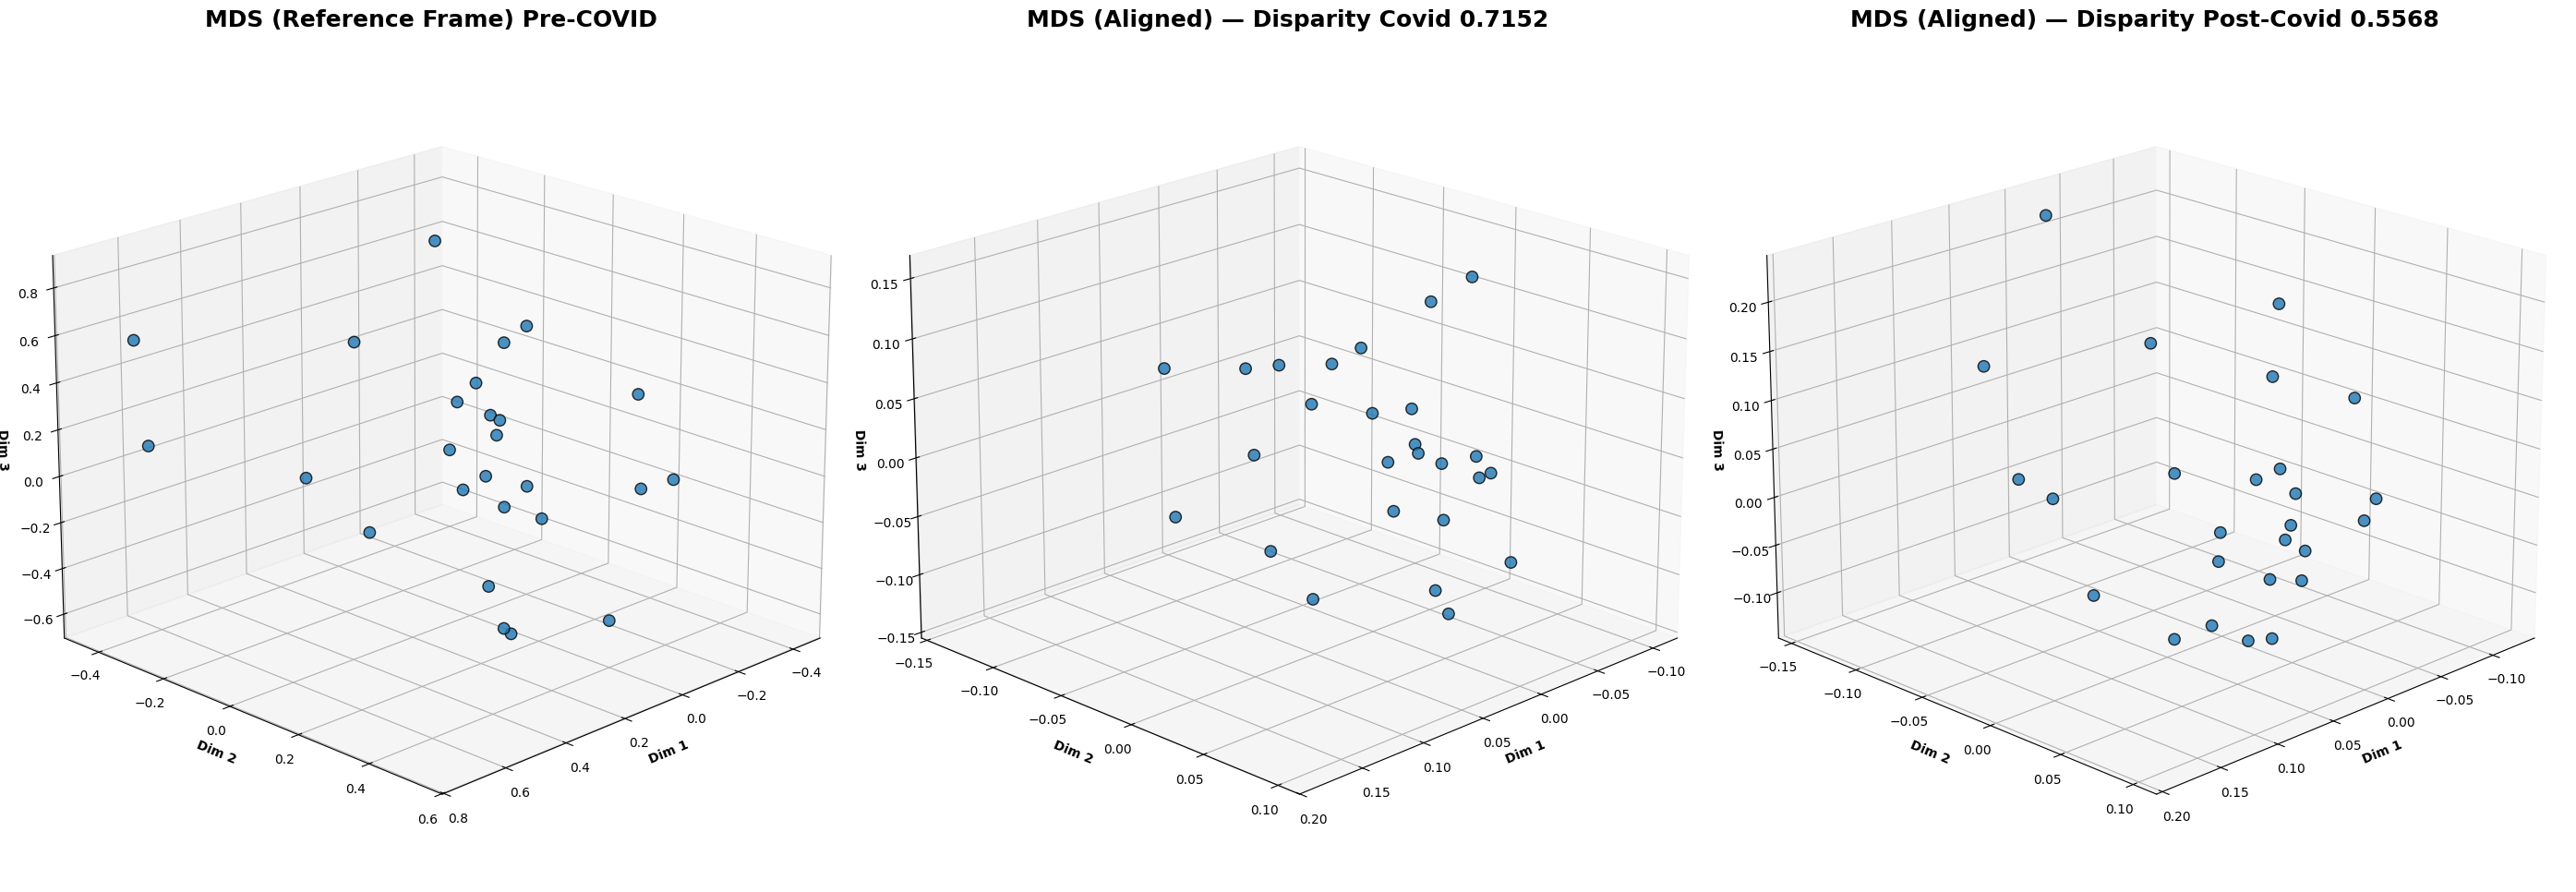

In [18]:
from mpl_toolkits.mplot3d import Axes3D

# Create the figure
fig = plt.subplots(1, 3, figsize=(28, 16), subplot_kw={'projection': '3d'})
fig, axes = fig # Unpacking for clarity

# plot tile display
titles = [
    "MDS (Reference Frame) Pre-COVID",
    f"MDS (Aligned) — Disparity Covid {(mds_results['covid']['disparity_to_pre']):.4f}",
    f"MDS (Aligned) — Disparity Post-Covid {(mds_results['post']['disparity_to_pre']):.4f}"
]

# Embeddings for each analysis
embeddings = [mds_results['pre']['coords'], mds_results['covid']['coords'], mds_results['post']['coords']]

# Iterate and plot
for ax, emb, title in zip(axes, embeddings, titles):
    # Scatter plot
    p = ax.scatter(
        emb[:, 0], emb[:, 1], emb[:, 2],
        # c=labels_z, 
        # cmap='tab10', 
        s=80, 
        edgecolor='black',
        alpha=0.8
    )

    # # Label each point with the crime type
    # for i, crime in enumerate(z_row_df.index):
    #     ax.text(emb[i, 0], emb[i, 1], emb[i, 2], crime, fontsize=10)

    # Apply the title with specific formatting
    ax.set_title(title, fontsize=18, fontweight='bold', pad=10)
    # Axis Labels
    ax.set_xlabel("Dim 1", fontweight='bold')
    ax.set_ylabel("Dim 2", fontweight='bold')
    ax.set_zlabel("Dim 3", fontweight='bold')
    
    # Adjust view angle for better depth perception
    ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## Dynamic Time Warping (DTW)

In [ ]:
from tslearn.metrics import cdist_dtw

# Helper function
def z_score(data):
    # Vectorized & Explicit NaN handling & population std (ddof=0)
    z_scored = pd.DataFrame(
        zscore(data, axis=1, nan_policy='omit'),
        index=data.index,
        columns=data.columns
    )
    return z_scored

In [20]:
# convert to Z-score
z_score_pre = z_score(counts_dfs['pre'])
z_score_covid = z_score(counts_dfs['covid'])
z_score_post = z_score(counts_dfs['post'])

In [24]:
# Shape (n_crime_types, n_months) 
dtw_df_pre = pd.DataFrame(cdist_dtw(z_score_pre), index=z_score_pre.index, columns=z_score_pre.index)
dtw_df_covid = pd.DataFrame(cdist_dtw(z_score_covid), index=z_score_covid.index, columns=z_score_covid.index)
dtw_df_post = pd.DataFrame(cdist_dtw(z_score_post), index=z_score_post.index, columns=z_score_post.index)
# Shape
dtw_df_pre.shape, dtw_df_covid.shape, dtw_df_post.shape

((26, 26), (26, 26), (26, 26))

In [26]:
# Convert square (26, 26) to condensed (325,)
dtw_vec_pre = squareform(dtw_df_pre)
dtw_vec_covid = squareform(dtw_df_covid)
dtw_vec_post = squareform(dtw_df_post)

# Shape
dtw_vec_pre.shape, dtw_vec_covid.shape, dtw_vec_post.shape

((325,), (325,), (325,))

In [27]:
# Dictionary
dtw_vecs = { "pre": dtw_vec_pre, 
              "covid": dtw_vec_covid, 
              "post": dtw_vec_post
            }

dtw_dfs = {"pre": dtw_vec_pre, 
           "covid": dtw_vec_covid, 
           "post": dtw_vec_post
          }

#### Linkage Method

In [28]:
# Run
all_results_dtw = best_method(dtw_vecs, msg='DTW Based Distance')

::: Processing Period: Pre DTW Based Distance:::
Method: complete | CCC: 0.6838
Method: average  | CCC: 0.7863
Method: median   | CCC: 0.6500
Winner for Pre: average

::: Processing Period: Covid DTW Based Distance:::
Method: complete | CCC: 0.7858
Method: average  | CCC: 0.8273
Method: median   | CCC: 0.7866
Winner for Covid: average

::: Processing Period: Post DTW Based Distance:::
Method: complete | CCC: 0.6351
Method: average  | CCC: 0.7793
Method: median   | CCC: 0.7336
Winner for Post: average



Average Linkage is the clear, robust winner across all three time periods.

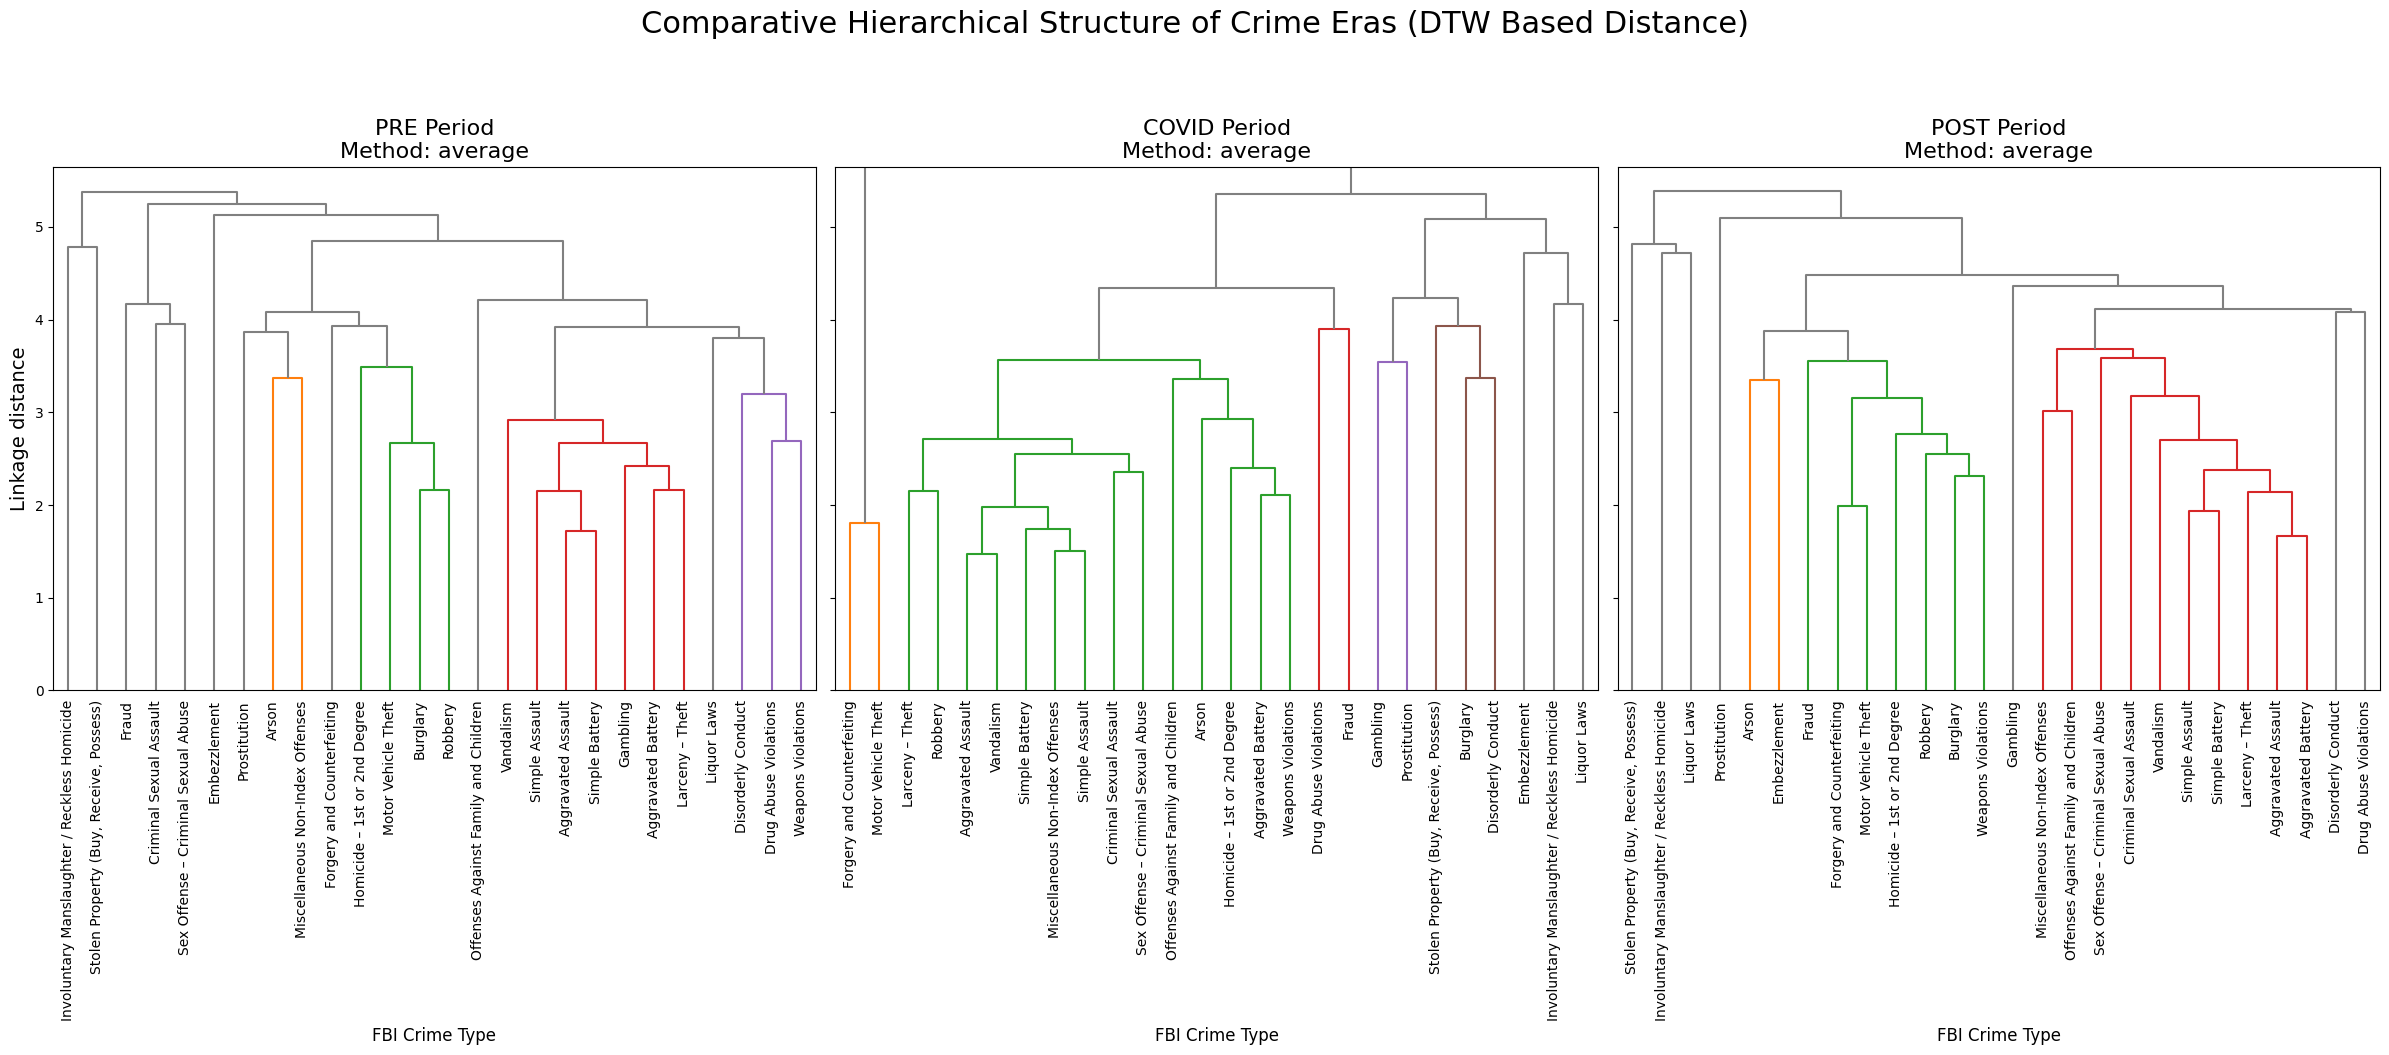

In [29]:
# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)

for i, period in enumerate(['pre', 'covid', 'post']):
    # Retrieve the best linkage and method name for this period
    Z_best = all_results_dtw[period]['best_linkage']
    best_m = all_results_dtw[period]['best_method']
    ax = axes[i]
    
    # Generate the dendrogram on the specific subplot axis
    hierarchy.dendrogram(
        Z_best, 
        labels=loaded_dfs[period].index, 
        leaf_rotation=90, # Increased rotation for better readability in subplots
        leaf_font_size=10,
        above_threshold_color='gray',
        ax=ax
    )
    
    # Formatting
    ax.set_title(f"{period.upper()} Period\nMethod: {best_m}", fontsize=16)
    ax.set_xlabel("FBI Crime Type", fontsize=12)
    
    # Only label the Y-axis for the first plot to avoid clutter
    if i == 0:
        ax.set_ylabel("Linkage distance", fontsize=14)

plt.suptitle("Comparative Hierarchical Structure of Crime Eras (DTW Based Distance)", fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

##  Z‑gap / R‑spike

In [30]:
structural_dia(all_results_dtw, msg='DTW Based Distance')

::: Structural Diagnostics for (PRE) DTW Based Distance :::
Global Gap (Z-method) suggests k = 7
Local Spikes (R-method) suggests k = 3
--------------------------------------------------
::: Structural Diagnostics for (COVID) DTW Based Distance :::
Global Gap (Z-method) suggests k = 15
Local Spikes (R-method) suggests k = 2
--------------------------------------------------
::: Structural Diagnostics for (POST) DTW Based Distance :::
Global Gap (Z-method) suggests k = 3
Local Spikes (R-method) suggests k = 4
--------------------------------------------------


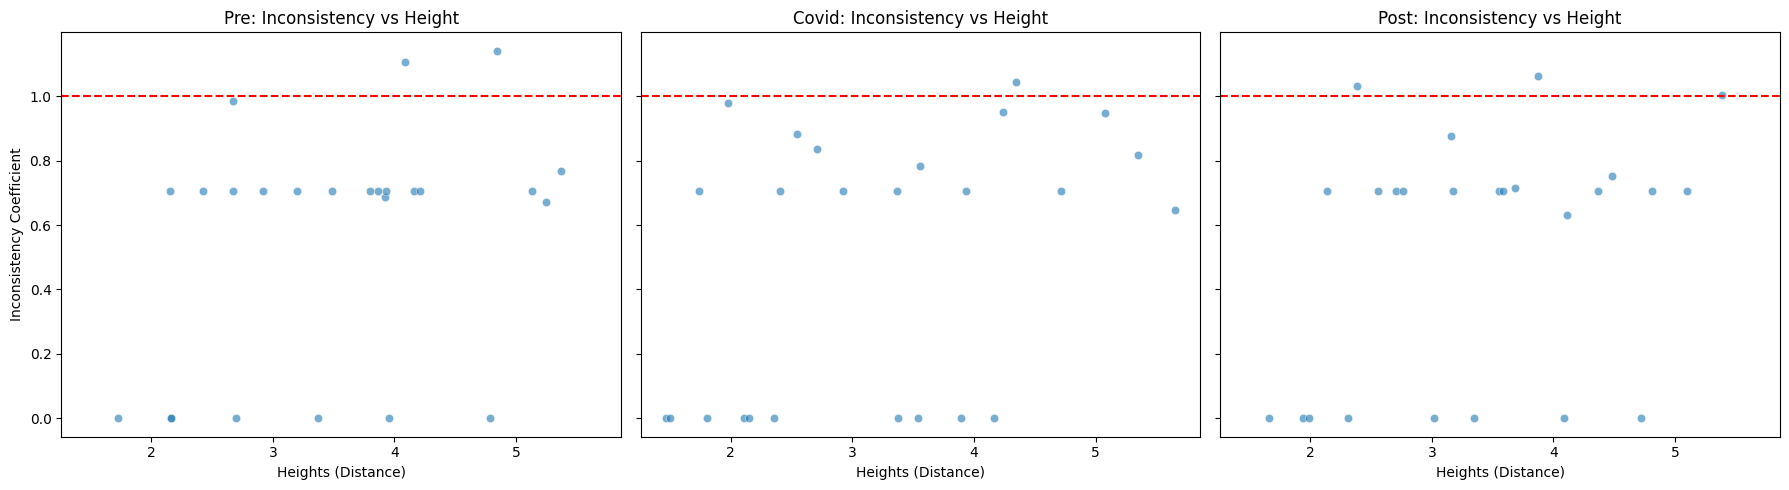

In [31]:
# Setup the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)
eras = ['pre', 'covid', 'post']
titles = ['Pre: Inconsistency vs Height', 'Covid: Inconsistency vs Height', 'Post: Inconsistency vs Height']

for i, era in enumerate(eras):
    # Get the linkage matrix for the specific era
    Z = all_results_dtw[era]['best_linkage']
    
    # Calculate Inconsistency (depth=2 is standard)
    # R columns: [mean, std, count, inconsistency_coefficient]
    R = hierarchy.inconsistent(Z, d=2)
    # Initialize variables
    heights = Z[:, 2]             # Distance at which clusters merge
    inconsistencies = R[:, 3]     # How 'natural' the clusters are
    
    # Plot on the specific axis
    sns.scatterplot(x=heights, y=inconsistencies, ax=axes[i], alpha=0.6)
    
    # Formatting
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Heights (Distance)")
    axes[i].axhline(1.0, color='red', linestyle='--', label='Threshold (1.0)')
    
    if i == 0:
        axes[i].set_ylabel("Inconsistency Coefficient")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kruskal, ranksums

# Statistical Testing (Omnibus)
h_stat, p_kruskal = kruskal(dist_vec_pre, dist_vec_covid, dist_vec_post)

# Post-hoc Testing (Pairwise)
# Using Bonferroni correction for 3 comparisons (alpha = 0.05 / 3 = 0.0167)
comparisons = [("Pre vs Covid", dist_vec_pre, dist_vec_covid), 
               ("Covid vs Post", dist_vec_covid, dist_vec_post), 
               ("Pre vs Post", dist_vec_pre, dist_vec_post)]

results = []
for label, v1, v2 in comparisons:
    stat, p_val = ranksums(v1, v2)
    results.append({
        "Comparison": label,
        "P-Value": round(p_val, 4),
        "Significant": p_val < 0.0167, # Adjusted Alpha: 0.05 / 3 = 0.01666
        "Median Diff": round(np.median(v2) - np.median(v1), 4)
    })

# Display Results
print(f"Kruskal-Wallis Test: H={h_stat:.4f}, p={p_kruskal:.4f}")
print("\nPairwise Comparisons:")
print(pd.DataFrame(results))

print("\nMedian Distances (Lower = More Synchronized):")
print(f"Pre: {np.median(dist_vec_pre):.4f} | Covid: {np.median(dist_vec_covid):.4f} | Post: {np.median(dist_vec_post):.4f}")

In [32]:
# Combine the condensed distance vectors into a single list for the test
data = [dtw_vec_pre, dtw_vec_covid, dtw_vec_post]

# condensed vectors
h_stat, p_val = kruskal(*data)

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("Significant difference found: Proceed to Dunn's Post-hoc and Clustering.")
else:
    print("No significant difference: Clusters may be based on noise.")

H-statistic: 12.0627
P-value: 2.4022e-03
Significant difference found: Proceed to Dunn's Post-hoc and Clustering.


In [33]:
# Bonferroni or Holm are recommended to avoid False Positives
p_values = sp.posthoc_dunn(data, p_adjust='bonferroni')
# p_values = sp.posthoc_dunn(data, p_adjust='holm')

# Rename columns/rows for clarity
p_values.columns = ['Pre', 'Covid', 'Post']
p_values.index = ['Pre', 'Covid', 'Post']

print(p_values)

            Pre     Covid      Post
Pre    1.000000  1.000000  0.003461
Covid  1.000000  1.000000  0.021722
Post   0.003461  0.021722  1.000000


## Clustering

In [31]:
# Run at your diagnostic k values
pre_clusters, anchors_pre = run_kmedoids(dtw_vecs['pre'], k=7, labels=crime_labels, era_name= 'Pre-COVID DTW Based Distance')
covid_clusters, anchors_covid = run_kmedoids(dtw_vecs['covid'], k=15, labels=crime_labels, era_name= 'COVID DTW Based Distance') 
post_clusters, anchors_post = run_kmedoids(dtw_vecs['post'], k=3, labels=crime_labels, era_name= 'Post-COVID DTW Based Distance')


::: Pre-COVID DTW Based Distance Results & total distance clustering has (Inertia):63.5575 with Silhouette Score: 0.045 :::
Cluster 1 [Medoid: Aggravated Assault]:
  Aggravated Assault, Simple Assault, Simple Battery...
Cluster 2 [Medoid: Vandalism]:
  Homicide – 1st or 2nd Degree, Vandalism...
Cluster 3 [Medoid: Aggravated Battery]:
  Aggravated Battery, Gambling, Larceny – Theft...
Cluster 4 [Medoid: Disorderly Conduct]:
  Disorderly Conduct, Drug Abuse Violations, Embezzlement, Liquor Laws, Stolen Property (Buy, Receive, Possess)...
Cluster 5 [Medoid: Miscellaneous Non-Index Offenses]:
  Arson, Criminal Sexual Assault, Fraud, Miscellaneous Non-Index Offenses, Prostitution...
Cluster 6 [Medoid: Offenses Against Family and Children]:
  Involuntary Manslaughter / Reckless Homicide, Offenses Against Family and Children...
Cluster 7 [Medoid: Robbery]:
  Burglary, Forgery and Counterfeiting, Motor Vehicle Theft, Robbery...

::: COVID DTW Based Distance Results & total distance clustering

In [32]:
# Run for the Pre era
post_tightness = calculate_cluster_tightness(dtw_vecs['pre'], pre_clusters, anchors_pre, crime_labels)

print("\n::: Pre-COVID DTW Based Distance Results :::")
post_tightness


::: Pre-COVID DTW Based Distance Results :::


,Cluster,Medoid,Avg_Dist_to_Medoid,Max_Dist_to_Medoid,Cluster_Size
0,1,Aggravated Assault,1.286893,2.137613,3
1,2,Vandalism,1.499078,2.998155,2
2,3,Aggravated Battery,1.490867,2.308040,3
3,4,Disorderly Conduct,3.175318,4.801387,6
4,5,Miscellaneous Non-Index Offenses,3.399916,4.852690,6
5,6,Offenses Against Family and Children,2.319178,4.638356,2
6,7,Robbery,2.034081,3.466533,4


In [33]:
# Run for the Pre era
post_tightness = calculate_cluster_tightness(dtw_vecs['covid'], pre_clusters, anchors_pre, crime_labels)

print("\n::: Pre-COVID DTW Based Distance Results :::")
post_tightness


::: Pre-COVID DTW Based Distance Results :::


,Cluster,Medoid,Avg_Dist_to_Medoid,Max_Dist_to_Medoid,Cluster_Size
0,1,Aggravated Assault,1.255185,2.265623,3
1,2,Vandalism,1.725307,3.450613,2
2,3,Aggravated Battery,3.092417,5.014896,3
3,4,Disorderly Conduct,4.390741,6.142243,6
4,5,Miscellaneous Non-Index Offenses,3.238407,5.886662,6
5,6,Offenses Against Family and Children,2.505213,5.010426,2
6,7,Robbery,3.059236,4.354520,4


In [34]:
# Run for the Pre era
post_tightness = calculate_cluster_tightness(dtw_vecs['post'], pre_clusters, anchors_pre, crime_labels)

print("\n::: Pre-COVID DTW Based Distance Results :::")
post_tightness


::: Pre-COVID DTW Based Distance Results :::


,Cluster,Medoid,Avg_Dist_to_Medoid,Max_Dist_to_Medoid,Cluster_Size
0,1,Aggravated Assault,1.608235,2.471454,3
1,2,Vandalism,1.414609,2.829217,2
2,3,Aggravated Battery,2.181029,4.389789,3
3,4,Disorderly Conduct,4.529907,6.016664,6
4,5,Miscellaneous Non-Index Offenses,3.735275,5.671456,6
5,6,Offenses Against Family and Children,2.517644,5.035288,2
6,7,Robbery,1.962375,2.672551,4
